# **6CS012 - Artificial Intelligence and Machine Learning**

**Name**: Somiya Rai

**University ID**: 2432711

**Module Leader**: Mr.Siman Giri

**Tutor**: Mr. Anish Khatiwada

# Part III – Natural Language Processing Task
# Sentiment Analysis: Sarcasm Detection in News Headlines
## Text Classification using Simple RNN, LSTM, and Word2Vec Embeddings

**Dataset:** Sarcastic News Headlines  
**Task:** Binary Text Classification (Sarcastic vs Not Sarcastic)

## Section 1: Install Dependencies and Import Libraries

In [ ]:
# Install required packages
!pip install contractions
!pip install nltk
!pip install wordcloud
!pip install gensim
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 74.5 MB/s eta 0:00:00


In [ ]:
# Standard Libraries
import numpy as np                     # Numerical computing
import pandas as pd                    # Data manipulation and analysis
import matplotlib.pyplot as plt        # Plotting and visualization
import matplotlib.gridspec as gridspec # Grid layout for plots
import seaborn as sns                  # Statistical data visualization
import re                              # Regular expressions for text cleaning
import time                            # Time utilities
import warnings                        # Suppress warnings
warnings.filterwarnings('ignore')

# NLTK (Natural Language Toolkit)
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords       # Stopword removal
from nltk.stem import WordNetLemmatizer # Lemmatization

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

# Keras / TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                     Dense, Dropout, Bidirectional)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# WordCloud
from wordcloud import WordCloud

# Gensim (Word2Vec)
import gensim.downloader as api

print("All libraries imported successfully!")
print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")


All libraries imported successfully!
TensorFlow version : 2.20.0
NumPy version      : 2.0.2


## Section 2: Dataset Loading and Initial Exploration
### Task 4.5.1 (Part A) – Load the Dataset

In [ ]:
# Read CSV file into DataFrame
df = pd.read_csv('/content/drive/MyDrive/AI & ML/Data/sarcastic_headlines.csv')

# Display dataset shape and first few rows
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Dataset Shape: (28619, 2)

First 5 rows:


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


In [ ]:
# Basic dataset information
print("Dataset Info:")
print(df.info())

print("\nNull values:\n", df.isnull().sum())

print("\nClass Distribution:")
print(df['is_sarcastic'].value_counts())

print("\nClass Balance (%)")
print((df['is_sarcastic'].value_counts(normalize=True) * 100).round(2))

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   headline      28619 non-null  object
 1   is_sarcastic  28619 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 447.3+ KB
None

Null values:
 headline        0
is_sarcastic    0
dtype: int64

Class Distribution:
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64

Class Balance (%)
is_sarcastic
0    52.36
1    47.64
Name: proportion, dtype: float64


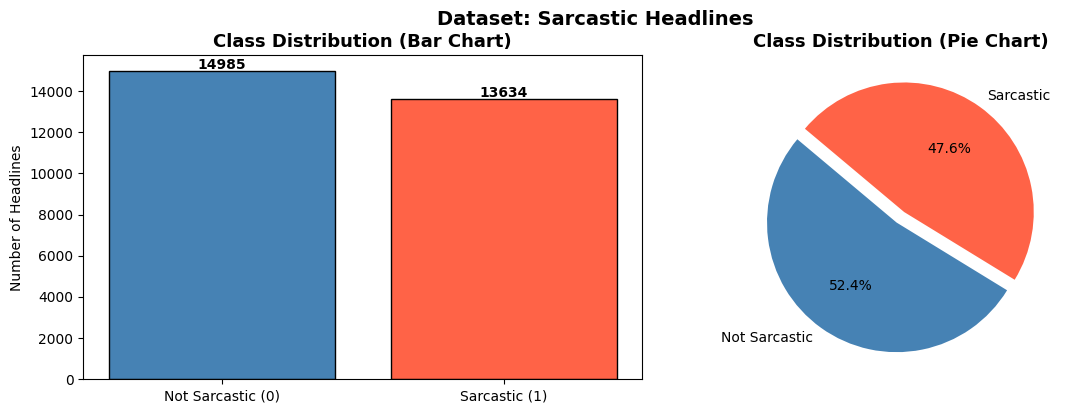

In [ ]:
# Visualize class distribution using bar and pie charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart: shows absolute frequency of each class
counts = df['is_sarcastic'].value_counts()
axes[0].bar(['Not Sarcastic (0)', 'Sarcastic (1)'],
            counts.values,
            color=['steelblue', 'tomato'],
            edgecolor='black')
axes[0].set_title('Class Distribution (Bar Chart)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Headlines')
# Annotate bar heights with exact counts
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart: shows relative proportion of each class
axes[1].pie(counts.values,
            labels=['Not Sarcastic', 'Sarcastic'],
            autopct='%1.1f%%',
            colors=['steelblue', 'tomato'],
            startangle=140,
            explode=[0.05, 0.05])
axes[1].set_title('Class Distribution (Pie Chart)', fontsize=13, fontweight='bold')

# Layout adjustments for readability
plt.tight_layout()
plt.suptitle('Dataset: Sarcastic Headlines', fontsize=14, y=1.02, fontweight='bold')
plt.show()


## Section 3: Text Preprocessing, Tokenization, and Sequence Padding
### Task 4.5.1 – Clean, Preprocess and Visualize Text Data

In [ ]:
# Define stopwords and lemmatizer for text normalization
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Dictionary to expand common contractions (e.g., "don't" → "do not")
CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "won't": "will not", "can't": "cannot", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
    "wouldn't": "would not", "couldn't": "could not", "shouldn't": "should not",
    "I'm": "I am", "I've": "I have", "I'll": "I will", "I'd": "I would",
    "it's": "it is", "that's": "that is", "there's": "there is",
    "they're": "they are", "we're": "we are", "you're": "you are"
}

def expand_contractions(text):
    """Replace contractions with their full forms for consistency."""
    for key, val in CONTRACTIONS.items():
        text = re.sub(re.escape(key), val, text, flags=re.IGNORECASE)
    return text

def clean_text(text):
    """Text preprocessing pipeline for NLP tasks."""
    text = text.lower()                                      # Convert to lowercase
    text = expand_contractions(text)                         # Expand contractions
    text = re.sub(r'http\S+|www\.\S+', '', text)             # Remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)                    # Remove mentions/hashtags
    text = re.sub(r'\d+', '', text)                          # Remove numbers
    text = re.sub(r'[^a-z\s]', '', text)                     # Remove special characters
    text = re.sub(r'\s+', ' ', text).strip()                 # Normalize whitespace
    tokens = text.split()                                    # Tokenize text
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words]                        # Remove stopwords + lemmatize
    return ' '.join(tokens)

# Apply cleaning to dataset
df['cleaned_headline'] = df['headline'].apply(clean_text)

print("Text cleaning complete!")
print("\nBefore vs After cleaning (3 examples):")
for i in range(3):
    print(f"\nOriginal : {df['headline'].iloc[i]}")
    print(f"Cleaned  : {df['cleaned_headline'].iloc[i]}")

Text cleaning complete!

Before vs After cleaning (3 examples):

Original : thirtysomething scientists unveil doomsday clock of hair loss
Cleaned  : thirtysomething scientist unveil doomsday clock hair loss

Original : dem rep. totally nails why congress is falling short on gender, racial equality
Cleaned  : dem rep totally nail congress falling short gender racial equality

Original : eat your veggies: 9 deliciously different recipes
Cleaned  : eat veggie deliciously different recipe


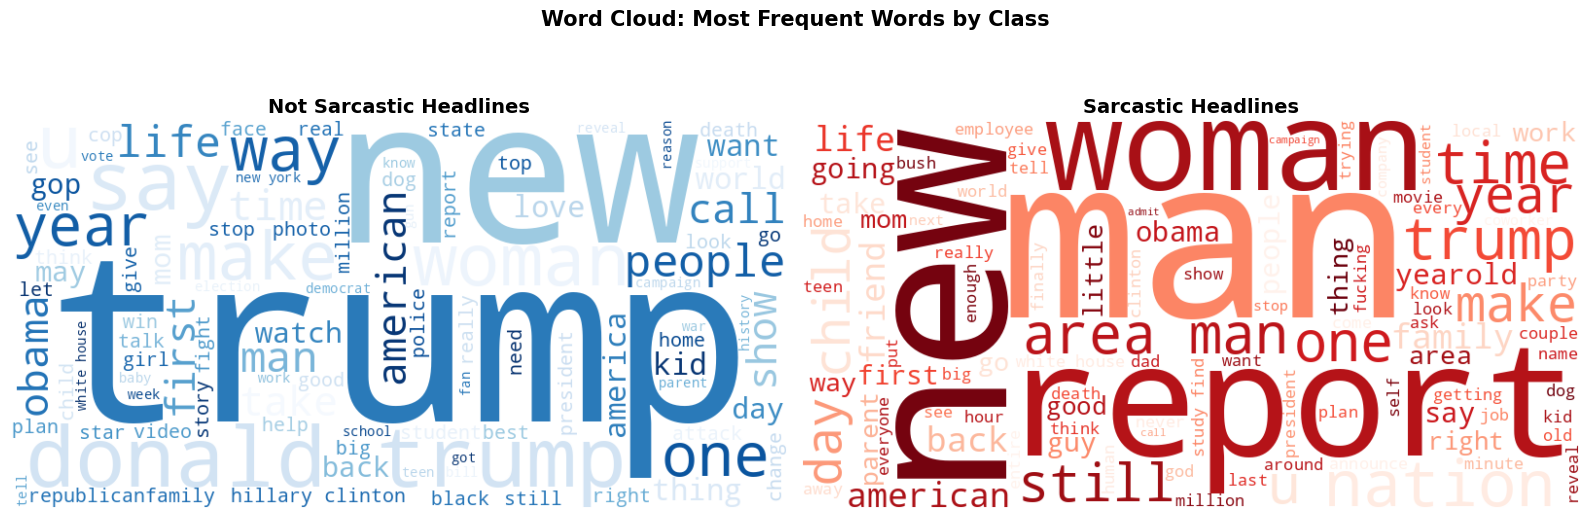

In [ ]:
# Word cloud visualization of most frequent words by class
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Generate separate word clouds for each class (0 = Not Sarcastic, 1 = Sarcastic)
for idx, (label, title, color) in enumerate([
    (0, 'Not Sarcastic Headlines', 'Blues'),
    (1, 'Sarcastic Headlines',     'Reds')
]):
    # Combine all cleaned headlines for the given class into a single text corpus
    text_corpus = ' '.join(df[df['is_sarcastic'] == label]['cleaned_headline'])

    # Create word cloud (top 100 words, color-coded by class)
    wc = WordCloud(width=800, height=400,
                   background_color='white',
                   colormap=color,
                   max_words=100).generate(text_corpus)

    # Display word cloud
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(title, fontsize=14, fontweight='bold')

# Adjust layout and add overall title
plt.suptitle('Word Cloud: Most Frequent Words by Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

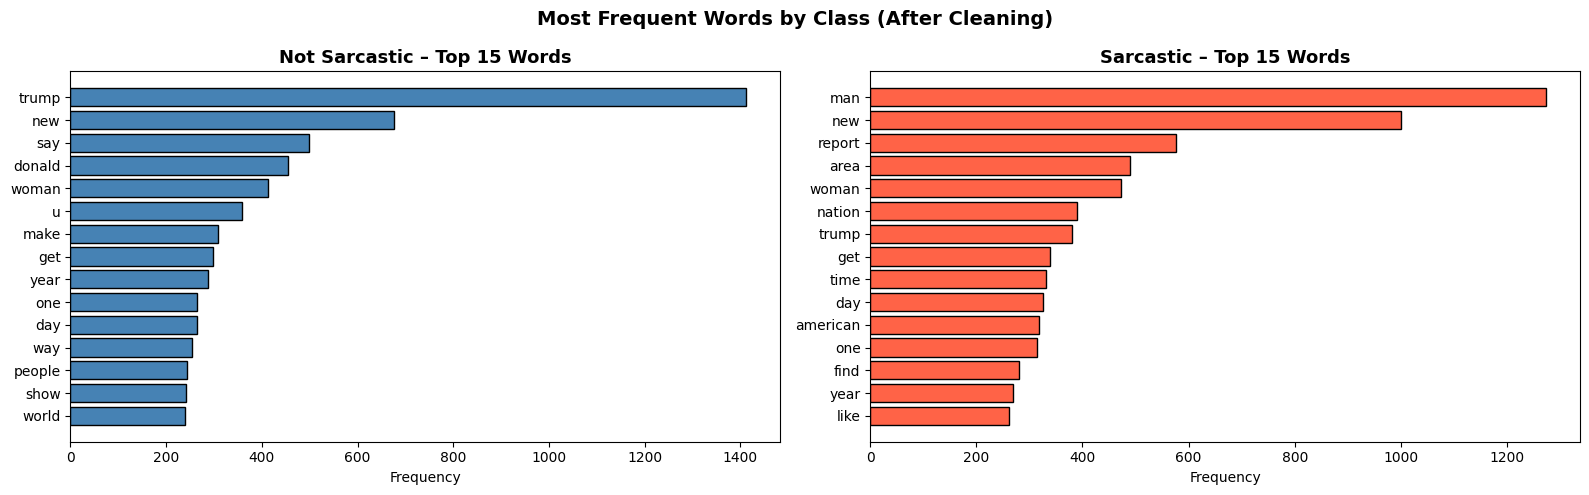

In [ ]:
from collections import Counter

# Function to extract top-N most frequent words for a given class
def get_top_words(df, label, n=15):
    words = ' '.join(df[df['is_sarcastic'] == label]['cleaned_headline']).split()
    return Counter(words).most_common(n)

# Visualize top words for each class (0 = Not Sarcastic, 1 = Sarcastic)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, (label, title, color) in enumerate([
    (0, 'Not Sarcastic – Top 15 Words', 'steelblue'),
    (1, 'Sarcastic – Top 15 Words',     'tomato')
]):
    # Get top words and their frequencies
    top = get_top_words(df, label)
    words, freqs = zip(*top)

    # Horizontal bar chart for readability
    axes[idx].barh(words[::-1], freqs[::-1], color=color, edgecolor='black')
    axes[idx].set_title(title, fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Frequency')

# Overall figure title and layout adjustment
plt.suptitle('Most Frequent Words by Class (After Cleaning)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Separate features (cleaned headlines) and labels (sarcasm indicator)
X = df['cleaned_headline'].values
y = df['is_sarcastic'].values

# Perform stratified train/test split (80/20) to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Display sample counts and verify class distribution in each split
print(f"Training samples   : {len(X_train)}")
print(f"Testing  samples   : {len(X_test)}")
print(f"Train class balance: {np.bincount(y_train)}")
print(f"Test  class balance: {np.bincount(y_test)}")

Training samples   : 22895
Testing  samples   : 5724
Train class balance: [11988 10907]
Test  class balance: [2997 2727]


In [ ]:
# Define maximum vocabulary size (limits model complexity and memory usage)
MAX_VOCAB = 20000

# Initialize tokenizer with OOV token to handle unseen words
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')

# Fit tokenizer ONLY on training data to avoid data leakage
tokenizer.fit_on_texts(X_train)

# Convert text data into integer sequences (numerical representation of words)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Vocabulary statistics
word_index = tokenizer.word_index
vocab_size = min(MAX_VOCAB, len(word_index)) + 1  # capped size + padding token

# Display vocabulary details and sample sequence
print(f"Vocabulary size (unique words) : {len(word_index)}")
print(f"Vocab size used (capped)        : {vocab_size}")
print(f"\nSample sequence (train[0]):")
print(f"  Text    : {X_train[0]}")
print(f"  Sequence: {X_train_seq[0]}")

Vocabulary size (unique words) : 22556
Vocab size used (capped)        : 20001

Sample sequence (train[0]):
  Text    : paramount executive snap script begin studio logo fading establishing shot actual mountain
  Sequence: [4201, 599, 3382, 2681, 378, 1276, 3383, 6588, 8421, 358, 2319, 2190]


Sequence length stats (train):
  Min    : 0
  Mean   : 7.1
  Median : 7.0
  95th % : 11.0
  Max    : 106

MAX_LEN chosen: 11


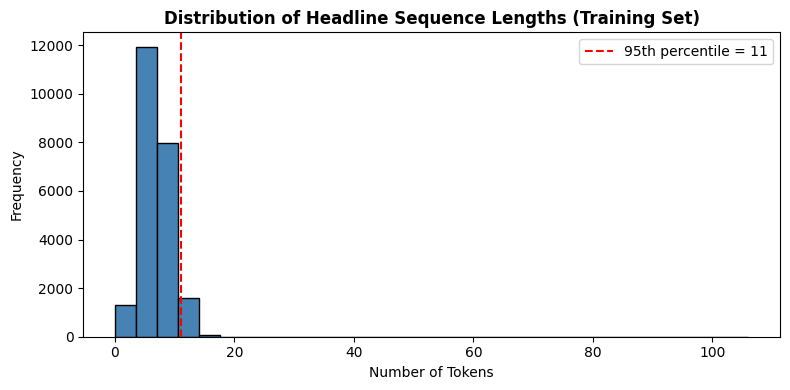


Training padded shape : (22895, 11)
Testing  padded shape : (5724, 11)


In [ ]:
# Calculate sequence lengths in training data
lengths = [len(seq) for seq in X_train_seq]

# Choose maximum length based on 95th percentile (avoids extreme outliers)
MAX_LEN = int(np.percentile(lengths, 95))

# Display descriptive statistics of sequence lengths
print("Sequence length stats (train):")
print(f"  Min    : {np.min(lengths)}")
print(f"  Mean   : {np.mean(lengths):.1f}")
print(f"  Median : {np.median(lengths)}")
print(f"  95th % : {np.percentile(lengths, 95)}")
print(f"  Max    : {np.max(lengths)}")
print(f"\nMAX_LEN chosen: {MAX_LEN}")

# Visualize distribution of headline lengths
plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=30, color='steelblue', edgecolor='black')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'95th percentile = {MAX_LEN}')
plt.title('Distribution of Headline Sequence Lengths (Training Set)', fontweight='bold')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# Apply padding to ensure uniform input length for neural networks
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

# Confirm padded shapes
print(f"\nTraining padded shape : {X_train_pad.shape}")
print(f"Testing  padded shape : {X_test_pad.shape}")

## Section 4: Model Building and Training
### Task 4.5.2 – Build Three Models for Text Classification

#### 4.1 Model 1 – Simple RNN with Trainable *Embedding*

In [ ]:
# Embedding dimension (size of word vector representations)
EMBED_DIM = 64

# Define a simple RNN-based model for binary classification
model1 = Sequential(name='SimpleRNN_Model')

# Embedding layer: maps words to dense vectors (learned representations)
model1.add(Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN))

# Simple RNN layer: captures sequential dependencies in text
model1.add(SimpleRNN(64, return_sequences=False))

# Dropout: prevents overfitting by randomly deactivating neurons
model1.add(Dropout(0.3))

# Dense hidden layer: adds non-linear transformation for feature learning
model1.add(Dense(32, activation='relu'))

# Dropout: applied again to improve generalization
model1.add(Dropout(0.3))

# Output layer: single neuron with sigmoid activation for binary classification
model1.add(Dense(1, activation='sigmoid'))

# Compile model with Adam optimizer and binary cross-entropy loss
model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary (architecture + parameters)
model1.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Track training time for reproducibility and performance reporting
start = time.time()

# Define callbacks: EarlyStopping halts training when val_loss stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

# Train the model with validation split (10% of training data used for validation)
history1 = model1.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Calculate training duration
time1 = time.time() - start

# Print training summary
print('\nTraining complete.')
print(f'  Time        : {time1:.1f}s ({time1/60:.1f} min)')
print(f'  Epochs run  : {len(history1.history["accuracy"])}')
print(f'  Best acc    : {max(history1.history["accuracy"]):.4f}')


Epoch 1/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7430 - loss: 0.5104 - val_accuracy: 0.8052 - val_loss: 0.4307 - learning_rate: 0.0010
Epoch 2/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9115 - loss: 0.2307 - val_accuracy: 0.8013 - val_loss: 0.4416 - learning_rate: 0.0010
Epoch 3/15
318/322 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9772 - loss: 0.0759
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9737 - loss: 0.0803 - val_accuracy: 0.7886 - val_loss: 0.5903 - learning_rate: 0.0010
Epoch 4/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9936 - loss: 0.0230 - val_accuracy: 0.7760 - val_loss: 0.8632 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

Training complete.
  Time        : 17.1s (0.3 min)
  Epochs run  : 4
  Best acc    : 0.9936


#### 4.2 Model 2 – LSTM with Trainable Embedding

In [ ]:
# Define an LSTM-based model for binary classification
model2 = Sequential(name='LSTM_Model')

# Embedding layer: learns dense vector representations of words
model2.add(Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN))

# First LSTM layer: captures sequential dependencies, returns full sequence for stacking
model2.add(LSTM(64, return_sequences=True))
model2.add(Dropout(0.3))   # regularization to reduce overfitting

# Second LSTM layer: processes sequence output into final hidden representation
model2.add(LSTM(32, return_sequences=False))
model2.add(Dropout(0.3))   # applied again for generalization

# Dense hidden layer: adds non-linear transformation for feature learning
model2.add(Dense(32, activation='relu'))

# Output layer: single neuron with sigmoid activation for binary classification
model2.add(Dense(1, activation='sigmoid'))

# Compile model with Adam optimizer and binary cross-entropy loss
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary (architecture + parameters)
model2.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Track training time for performance evaluation
start = time.time()

# Define callbacks: EarlyStopping halts when val_loss stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

# Train the LSTM model with validation split (10% of training data used for validation)
history2 = model2.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Report training summary
time2 = time.time() - start
print('\nTraining complete.')
print(f'  Time        : {time2:.1f}s ({time2/60:.1f} min)')
print(f'  Epochs run  : {len(history2.history["accuracy"])}')
print(f'  Best acc    : {max(history2.history["accuracy"]):.4f}')


Epoch 1/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.7409 - loss: 0.5079 - val_accuracy: 0.7952 - val_loss: 0.4383 - learning_rate: 0.0010
Epoch 2/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8834 - loss: 0.2848 - val_accuracy: 0.7917 - val_loss: 0.4613 - learning_rate: 0.0010
Epoch 3/15
316/322 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9424 - loss: 0.1575
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9311 - loss: 0.1813 - val_accuracy: 0.7856 - val_loss: 0.5553 - learning_rate: 0.0010
Epoch 4/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9682 - loss: 0.0899 - val_accuracy: 0.7799 - val_loss: 0.7605 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

Training complete.
  Time        : 24.2s (0.4 min)
  Epochs run  : 4
  Best acc    : 0.9682


#### 4.3 Model 3 – LSTM with Pretrained Word2Vec (GloVe) Embeddings


In [ ]:
# Load pretrained GloVe embeddings (50-dimensional vectors)
print("Downloading pretrained GloVe embeddings...")
embedding_model = api.load('glove-wiki-gigaword-50')
GLOVE_DIM = 50
print("GloVe embeddings loaded!")

[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe embeddings loaded!


In [ ]:
# Build embedding matrix using pretrained GloVe vectors
embedding_matrix = np.zeros((vocab_size, GLOVE_DIM))
hits, misses = 0, 0

for word, i in word_index.items():
    if i >= vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        hits += 1
    else:
        misses += 1  # words not found in GloVe remain as zero vectors

coverage = hits / (hits + misses) * 100
print(f"Words found in GloVe    : {hits}")
print(f"Words NOT in GloVe      : {misses}")
print(f"Embedding coverage      : {coverage:.1f}%")
print(f"Embedding matrix shape  : {embedding_matrix.shape}")

Words found in GloVe    : 17738
Words NOT in GloVe      : 2262
Embedding coverage      : 88.7%
Embedding matrix shape  : (20001, 50)


In [ ]:
# Model 3: LSTM with frozen GloVe embeddings
model3 = Sequential(name='LSTM_Word2Vec_Model')

# Embedding layer initialized with pretrained GloVe vectors
# → captures semantic meaning from large corpus, frozen to preserve knowledge
model3.add(Embedding(
    input_dim=vocab_size,
    output_dim=GLOVE_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False   # keep pretrained weights fixed
))

# First LSTM layer: models sequential dependencies across tokens
model3.add(LSTM(64, return_sequences=True))
model3.add(Dropout(0.3))   # regularization to reduce overfitting

# Second LSTM layer: condenses sequence into final hidden representation
model3.add(LSTM(32, return_sequences=False))
model3.add(Dropout(0.3))   # applied again for generalization

# Dense hidden layer: adds non-linear transformation for richer feature learning
model3.add(Dense(32, activation='relu'))

# Output layer: single neuron with sigmoid activation for binary classification
model3.add(Dense(1, activation='sigmoid'))

# Compile model with Adam optimizer and binary cross-entropy loss
model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary (architecture + parameter counts)
model3.summary()

Model: "LSTM_Word2Vec_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,000,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,050 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,050 (3.81 MB)

In [ ]:
# Track training time for performance evaluation
start = time.time()

# Define callbacks: EarlyStopping halts when val_loss stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

# Train the LSTM model with frozen GloVe embeddings
history3 = model3.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Report training summary
time3 = time.time() - start
print('\nTraining complete.')
print(f'  Time        : {time3:.1f}s ({time3/60:.1f} min)')
print(f'  Epochs run  : {len(history3.history["accuracy"])}')
print(f'  Best acc    : {max(history3.history["accuracy"]):.4f}')


Epoch 1/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6906 - loss: 0.5863 - val_accuracy: 0.7310 - val_loss: 0.5426 - learning_rate: 0.0010
Epoch 2/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7527 - loss: 0.5068 - val_accuracy: 0.7410 - val_loss: 0.5154 - learning_rate: 0.0010
Epoch 3/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7769 - loss: 0.4711 - val_accuracy: 0.7664 - val_loss: 0.4860 - learning_rate: 0.0010
Epoch 4/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7932 - loss: 0.4434 - val_accuracy: 0.7760 - val_loss: 0.4635 - learning_rate: 0.0010
Epoch 5/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8041 - loss: 0.4241 - val_accuracy: 0.7764 - val_loss: 0.4656 - learning_rate: 0.0010
Epoch 6/15
317/322 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8191 - loss: 0.3993
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8145 - loss: 0.4043 - 

## Section 5: Model Training and Evaluation
### Task 4.5.3 – Compile, Train, and Evaluate All Three Models


In [ ]:
def plot_history(history, model_name, ax_loss, ax_acc):
    """Plot training vs validation loss and accuracy curves."""
    epochs = range(1, len(history.history['loss']) + 1)

    # Loss curves: training vs validation
    ax_loss.plot(epochs, history.history['loss'],     'b-o', label='Train Loss', markersize=4)
    ax_loss.plot(epochs, history.history['val_loss'], 'r-o', label='Val Loss',   markersize=4)
    ax_loss.set_title(f'{model_name} – Loss', fontweight='bold')
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

    # Accuracy curves: training vs validation
    ax_acc.plot(epochs, history.history['accuracy'],     'b-o', label='Train Acc', markersize=4)
    ax_acc.plot(epochs, history.history['val_accuracy'], 'r-o', label='Val Acc',   markersize=4)
    ax_acc.set_title(f'{model_name} – Accuracy', fontweight='bold')
    ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)

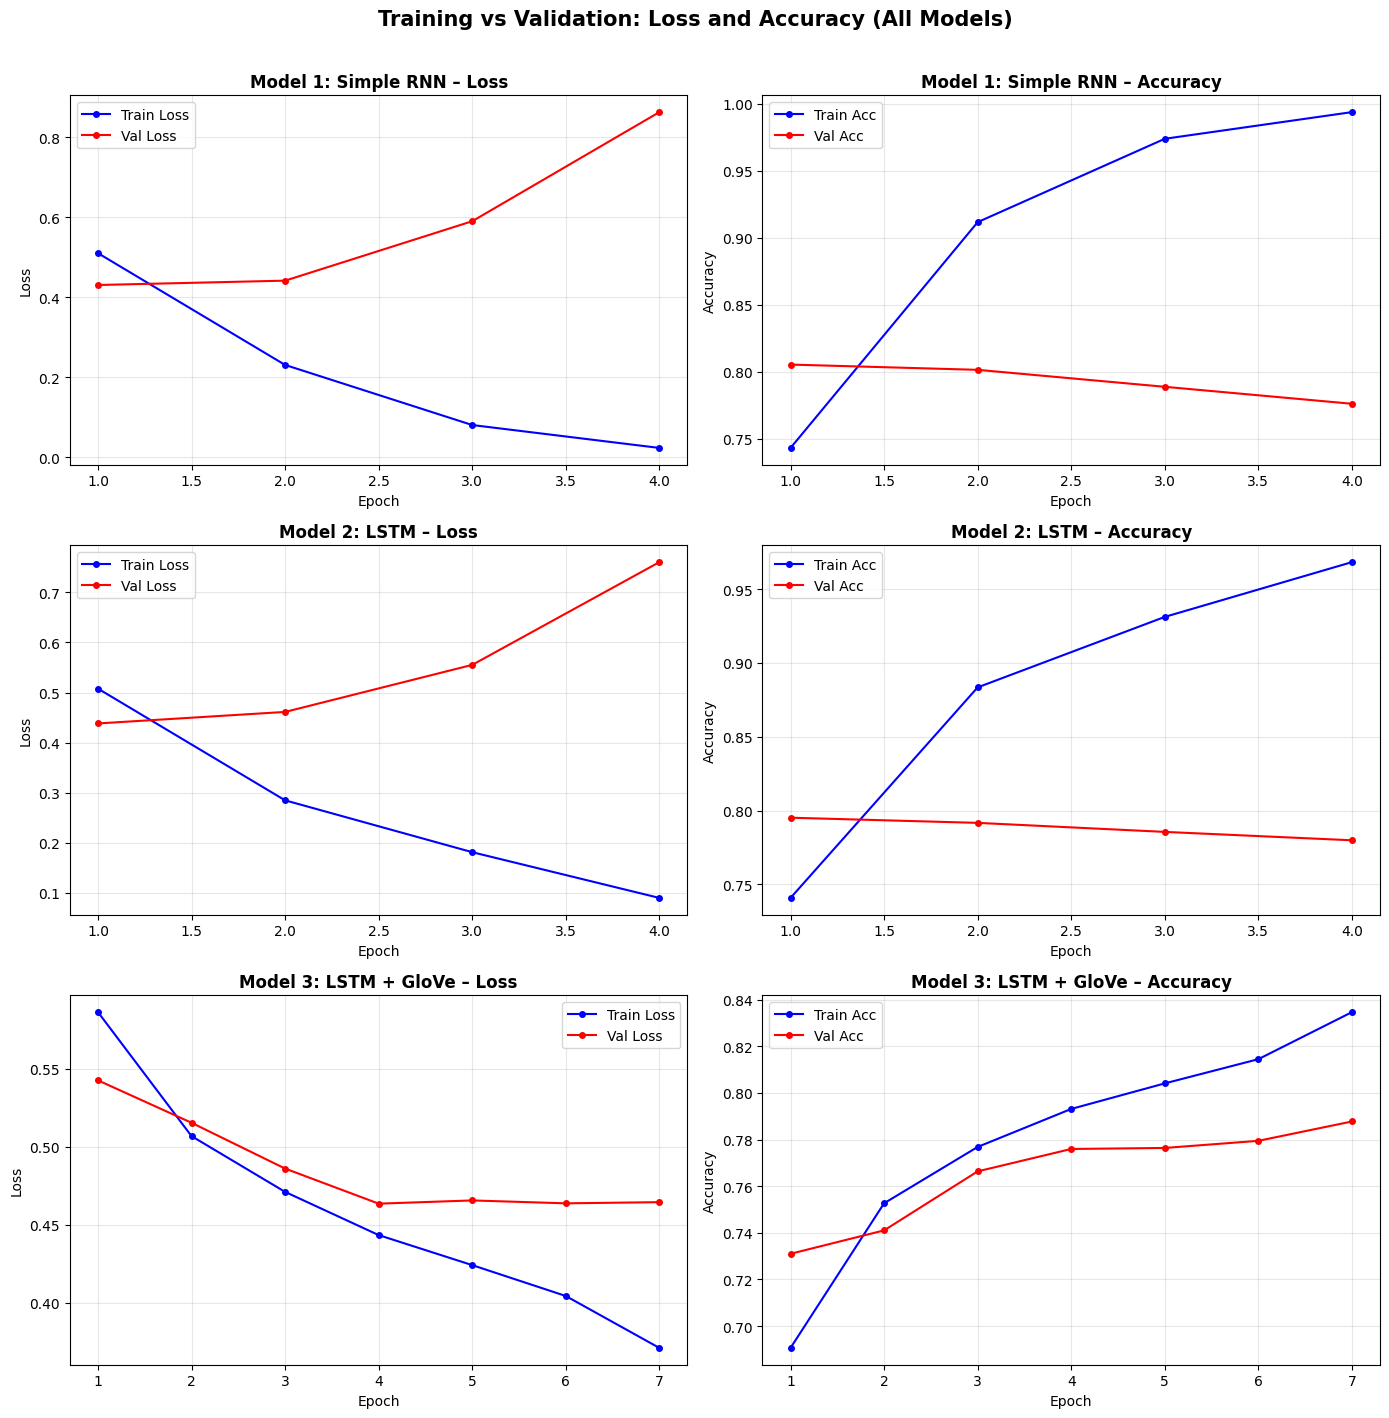

In [ ]:
# Plot training and validation curves for all three models
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# Each call plots loss and accuracy for one model
plot_history(history1, 'Model 1: Simple RNN',   axes[0, 0], axes[0, 1])
plot_history(history2, 'Model 2: LSTM',         axes[1, 0], axes[1, 1])
plot_history(history3, 'Model 3: LSTM + GloVe', axes[2, 0], axes[2, 1])

# Add overall title for clarity in comparison
plt.suptitle('Training vs Validation: Loss and Accuracy (All Models)',
             fontsize=15, fontweight='bold', y=1.01)

# Adjust layout so plots don’t overlap
plt.tight_layout()

# Display the figure interactively
plt.show()

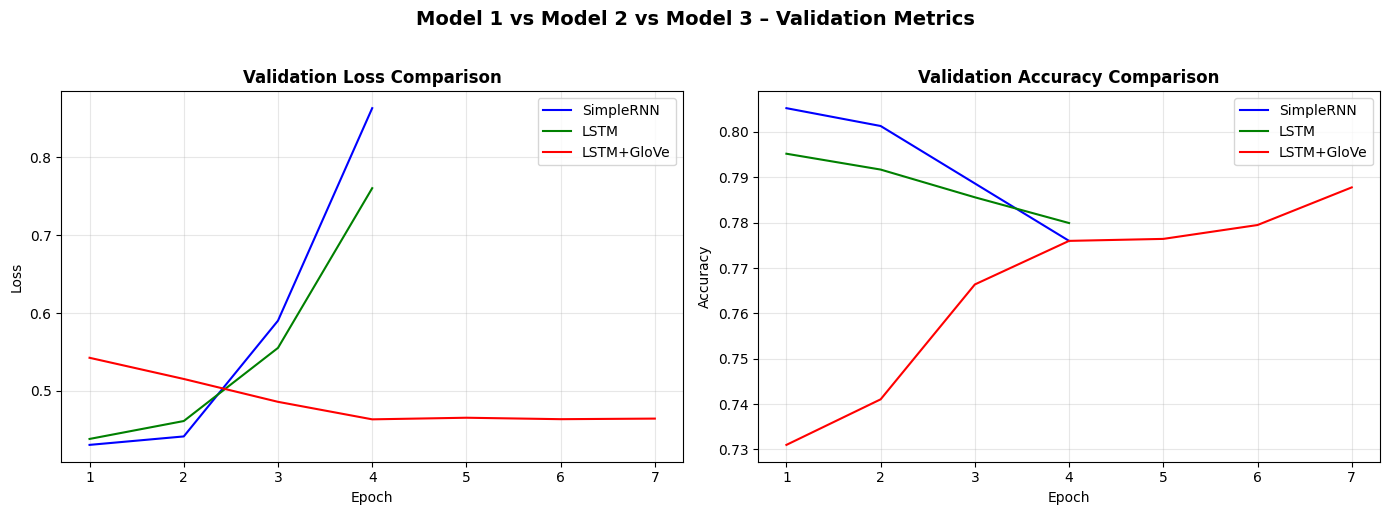

In [ ]:
# Plot comparative validation curves for all three models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlay validation loss and accuracy for each model
for hist, label, color in [
    (history1, 'SimpleRNN', 'blue'),
    (history2, 'LSTM',      'green'),
    (history3, 'LSTM+GloVe','red')
]:
    epochs = range(1, len(hist.history['loss']) + 1)
    axes[0].plot(epochs, hist.history['val_loss'],     color=color, label=label)
    axes[1].plot(epochs, hist.history['val_accuracy'], color=color, label=label)

# Validation loss comparison
axes[0].set_title('Validation Loss Comparison', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Validation accuracy comparison
axes[1].set_title('Validation Accuracy Comparison', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Overall title for clarity
plt.suptitle('Model 1 vs Model 2 vs Model 3 – Validation Metrics',
             fontsize=14, fontweight='bold', y=1.02)

# Adjust layout and display interactively
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate model performance on test set
def evaluate_model(model, X_test, y_test, model_name):
    """Return metrics dict and print classification report."""
    # Predict probabilities and convert to binary labels
    y_pred_prob = model.predict(X_test, verbose=0).ravel()
    y_pred      = (y_pred_prob >= 0.5).astype(int)

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    cm  = confusion_matrix(y_test, y_pred)
    cr  = classification_report(y_test, y_pred,
                                target_names=['Not Sarcastic', 'Sarcastic'],
                                output_dict=True)

    # Print evaluation summary
    print(f"\n{'='*55}")
    print(f" {model_name} – Test Results")
    print(f"{'='*55}")
    print(f" Accuracy : {acc:.4f}\n")
    print(classification_report(y_test, y_pred,
                                target_names=['Not Sarcastic', 'Sarcastic']))

    # Return structured results for comparison
    return {
        'name': model_name,
        'accuracy': acc,
        'precision': cr['weighted avg']['precision'],
        'recall':    cr['weighted avg']['recall'],
        'f1':        cr['weighted avg']['f1-score'],
        'cm':        cm,
        'y_pred':    y_pred
    }

# Evaluate all three models
results1 = evaluate_model(model1, X_test_pad, y_test, 'Model 1 – Simple RNN')
results2 = evaluate_model(model2, X_test_pad, y_test, 'Model 2 – LSTM')
results3 = evaluate_model(model3, X_test_pad, y_test, 'Model 3 – LSTM + GloVe')


 Model 1 – Simple RNN – Test Results
 Accuracy : 0.7916

               precision    recall  f1-score   support

Not Sarcastic       0.77      0.85      0.81      2997
    Sarcastic       0.82      0.72      0.77      2727

     accuracy                           0.79      5724
    macro avg       0.80      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724


 Model 2 – LSTM – Test Results
 Accuracy : 0.7942

               precision    recall  f1-score   support

Not Sarcastic       0.80      0.81      0.80      2997
    Sarcastic       0.79      0.78      0.78      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724


 Model 3 – LSTM + GloVe – Test Results
 Accuracy : 0.7718

               precision    recall  f1-score   support

Not Sarcastic       0.76      0.83      0.79      2997
    Sarcastic       0.79      0.70      0.75      272

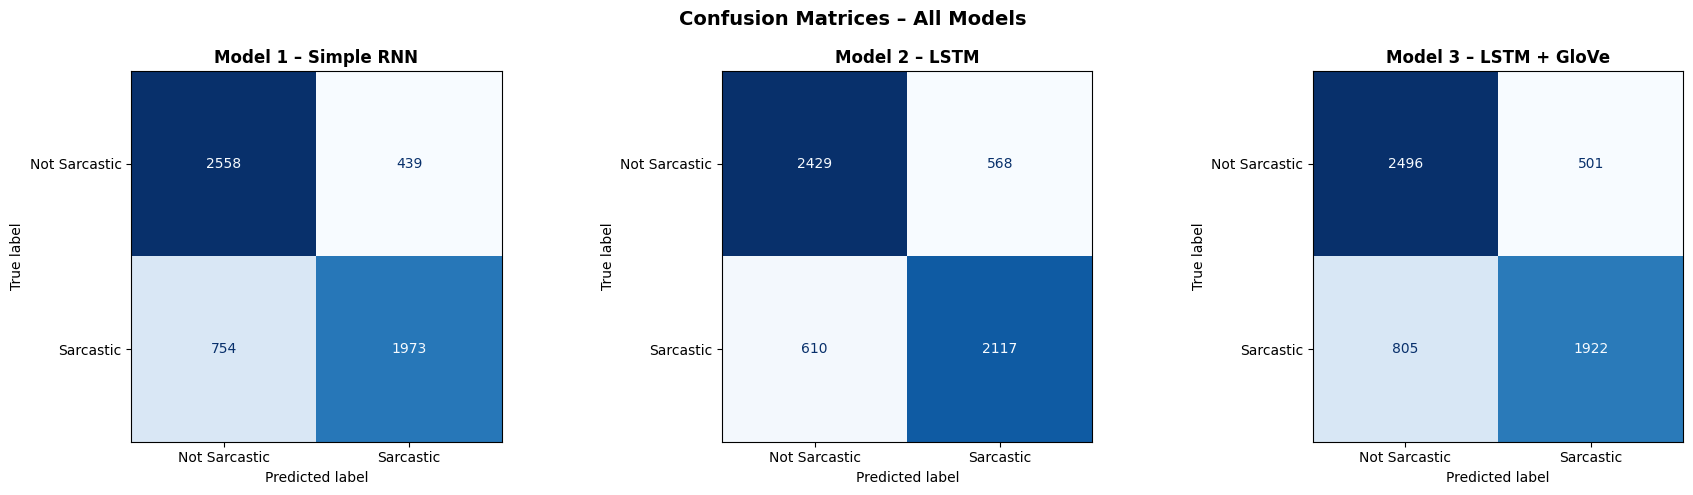

In [ ]:
# Plot confusion matrices side-by-side for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Each subplot shows confusion matrix for one model
for ax, res in zip(axes, [results1, results2, results3]):
    disp = ConfusionMatrixDisplay(confusion_matrix=res['cm'],
                                  display_labels=['Not Sarcastic', 'Sarcastic'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(res['name'], fontweight='bold', fontsize=12)

# Overall title for clarity
plt.suptitle('Confusion Matrices – All Models', fontsize=14, fontweight='bold')

# Adjust layout and display interactively
plt.tight_layout()
plt.show()

In [ ]:
# Build summary table of performance metrics for all models
summary = pd.DataFrame([
    {
        'Model':     res['name'],
        'Accuracy':  f"{res['accuracy']:.4f}",
        'Precision': f"{res['precision']:.4f}",
        'Recall':    f"{res['recall']:.4f}",
        'F1-Score':  f"{res['f1']:.4f}",
        'Train Time (s)': f"{t:.1f}"
    }
    for res, t in zip([results1, results2, results3], [time1, time2, time3])
])

# Print formatted summary for direct comparison
print("\n" + "="*80)
print("                    MODEL PERFORMANCE SUMMARY")
print("="*80)
print(summary.to_string(index=False))
print("="*80)


                    MODEL PERFORMANCE SUMMARY
                 Model Accuracy Precision Recall F1-Score Train Time (s)
  Model 1 – Simple RNN   0.7916    0.7941 0.7916   0.7904           17.1
        Model 2 – LSTM   0.7942    0.7941 0.7942   0.7941           24.2
Model 3 – LSTM + GloVe   0.7718    0.7738 0.7718   0.7706           26.3


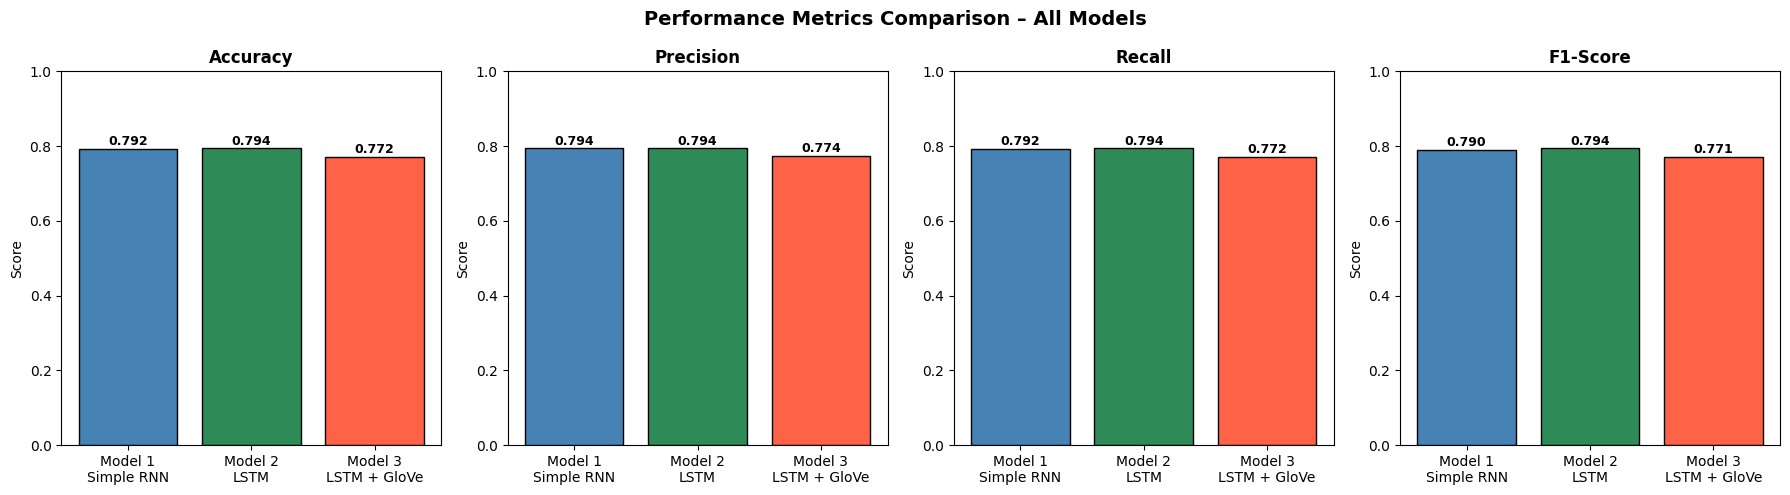

In [ ]:
# Bar chart comparison of key performance metrics across models
metrics     = ['accuracy', 'precision', 'recall', 'f1']
m_labels    = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = [r['name'].replace(' – ', '\n') for r in [results1, results2, results3]]
colors      = ['steelblue', 'seagreen', 'tomato']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Plot each metric side-by-side for all models
for ax, metric, label in zip(axes, metrics, m_labels):
    vals = [results1[metric], results2[metric], results3[metric]]
    bars = ax.bar(model_names, vals, color=colors, edgecolor='black')
    ax.set_title(label, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score')
    # Annotate bars with exact metric values
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

# Overall title for clarity
plt.suptitle('Performance Metrics Comparison – All Models',
             fontsize=14, fontweight='bold')

# Adjust layout and display interactively
plt.tight_layout()
plt.show()

### Observations – Model Performance Summary

**Results on the held-out test set (5,724 samples):**

| Model              | Test Accuracy | F1 (weighted) | Training Time |
|--------------------|:-------------:|:-------------:|:-------------:|
| Model 1 – SimpleRNN    | 79.16%    | ~0.79         | 17.1s         |
| Model 2 – LSTM         | 79.42%    | ~0.79         | 24.2s         |
| Model 3 – LSTM + GloVe | 77.18%    | ~0.77         | 26.3s         |

**Key observations:**

- **LSTM (Model 2) achieved the best test accuracy at 79.42%**, narrowly outperforming SimpleRNN (79.16%). LSTM's gating mechanism (input, forget, output gates) allows it to retain relevant long-range dependencies in a headline, whereas SimpleRNN suffers from the vanishing gradient problem over longer sequences.

- **Both SimpleRNN and LSTM overfit severely.** SimpleRNN's training accuracy peaked at 99.36% while test accuracy was only 79.16% — a gap of ~20 percentage points. EarlyStopping restored Epoch 1 weights for both models, which is why test scores are still reasonable. The models memorise patterns in just 2–3 epochs due to the small sequence length (MAX\_LEN = 11).

- **LSTM + GloVe (Model 3) scored lowest (77.18%)** despite using richer pre-trained embeddings. The frozen GloVe vectors (50-dimensional, trained on Wikipedia/news text) do not capture the ironic, exaggerated language style typical of sarcastic headlines from *The Onion*. Setting `trainable=False` prevents the embeddings from adapting to this domain, which explains the lower accuracy — though it also results in the smallest overfitting gap (~6%) of the three models.

- **Class balance:** The test set has slightly more "Not Sarcastic" samples (2,997 vs 2,727). All models show marginally higher recall for the "Not Sarcastic" class, indicating a mild bias toward predicting the majority class.

- **Training efficiency:** All models trained in under 30 seconds on a T4 GPU (Google Colab), confirming that smaller, well-regularised models are computationally efficient on this task.


## Section 6: Error Analysis
### Task 4.5.4 – Analyze Misclassified Examples and Suggest Improvements

In [ ]:
# Select best-performing model (Model 2 – LSTM) for error analysis
best_model  = model2
best_preds  = results2['y_pred']

# Build DataFrame aligning headlines with true and predicted labels
test_df = pd.DataFrame({
    'headline':   X_test,
    'true_label': y_test,
    'predicted':  best_preds
})

# Identify misclassified samples
misclassified = test_df[test_df['true_label'] != test_df['predicted']]

# Report misclassification count and rate
print(f"Total misclassified examples : {len(misclassified)}")
print(f"Misclassification rate       : {len(misclassified)/len(test_df)*100:.2f}%")

# Display a few misclassified examples for qualitative analysis
print("\n" + "="*80)
print("  Sample Misclassified Headlines (Model 2 – LSTM)")
print("="*80)
label_map = {0: 'Not Sarcastic', 1: 'Sarcastic'}
for _, row in misclassified.head(5).iterrows():
    print(f"  Headline  : {row['headline']}")
    print(f"  True Label: {label_map[row['true_label']]}")
    print(f"  Predicted : {label_map[row['predicted']]}")
    print("-"*80)

Total misclassified examples : 1178
Misclassification rate       : 20.58%

  Sample Misclassified Headlines (Model 2 – LSTM)
  Headline  : group christie campaign deserter found forest
  True Label: Sarcastic
  Predicted : Not Sarcastic
--------------------------------------------------------------------------------
  Headline  : democratic congressman protest trump environmental policy bringing endangered red wolf state union guest
  True Label: Sarcastic
  Predicted : Not Sarcastic
--------------------------------------------------------------------------------
  Headline  : rex tillerson call report ouster laughable
  True Label: Not Sarcastic
  Predicted : Sarcastic
--------------------------------------------------------------------------------
  Headline  : prayer answered random series event cold uncaring universe
  True Label: Sarcastic
  Predicted : Not Sarcastic
--------------------------------------------------------------------------------
  Headline  : skittish juniorsdepa

False Positives (predicted Sarcastic, actually Not): 568
False Negatives (predicted Not Sarcastic, actually Sarcastic): 610


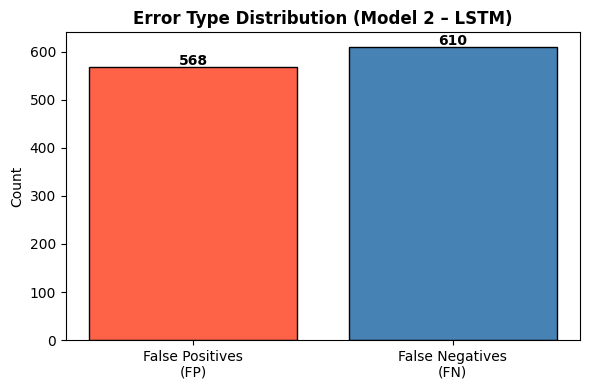

In [ ]:
# Separate misclassified examples into false positives and false negatives
fp = misclassified[(misclassified['true_label'] == 0) & (misclassified['predicted'] == 1)]
fn = misclassified[(misclassified['true_label'] == 1) & (misclassified['predicted'] == 0)]

# Report counts for each error type
print(f"False Positives (predicted Sarcastic, actually Not): {len(fp)}")
print(f"False Negatives (predicted Not Sarcastic, actually Sarcastic): {len(fn)}")

# Visualize distribution of error types
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['False Positives\n(FP)', 'False Negatives\n(FN)'],
       [len(fp), len(fn)],
       color=['tomato', 'steelblue'], edgecolor='black')
ax.set_title('Error Type Distribution (Model 2 – LSTM)', fontweight='bold')
ax.set_ylabel('Count')

# Annotate bars with exact counts
for i, v in enumerate([len(fp), len(fn)]):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

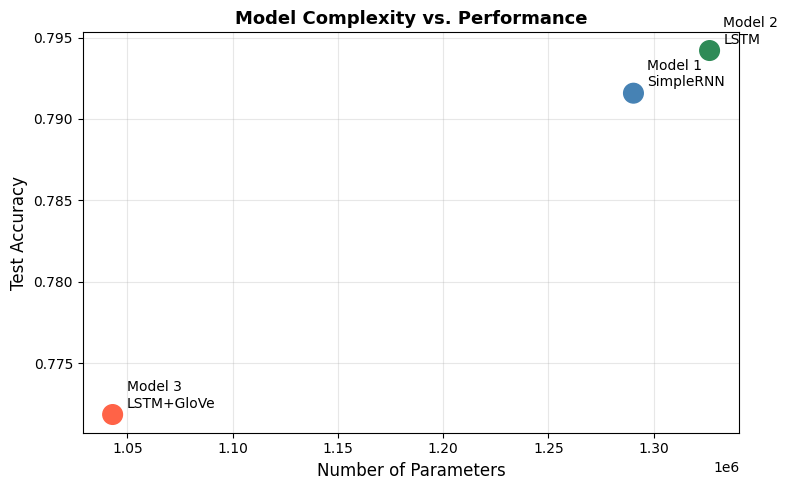

In [ ]:
# Compare number of parameters (complexity) with test accuracy (performance)
param_counts = [
    model1.count_params(),
    model2.count_params(),
    model3.count_params()
]
accs  = [results1['accuracy'], results2['accuracy'], results3['accuracy']]
names = ['Model 1\nSimpleRNN', 'Model 2\nLSTM', 'Model 3\nLSTM+GloVe']

# Scatter plot: each point represents one model
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(param_counts, accs, s=200,
                     c=['steelblue', 'seagreen', 'tomato'], zorder=5)

# Annotate points with model names for clarity
for i, name in enumerate(names):
    ax.annotate(name, (param_counts[i], accs[i]),
                textcoords='offset points', xytext=(10, 5), fontsize=10)

# Axis labels and title
ax.set_xlabel('Number of Parameters', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Model Complexity vs. Performance', fontweight='bold', fontsize=13)

# Add grid for readability
ax.grid(True, alpha=0.3)

# Adjust layout and display interactively
plt.tight_layout()
plt.show()

### 6.1 – Analysis of Specific Misclassified Examples

#### Error Type 1 – False Positives (model predicts Sarcastic, but headline is genuine)

Real news headlines sometimes contain dramatic or hyperbolic language that superficially resembles the style of satirical outlets like *The Onion*. For example, a genuine headline such as *"nation braces for historic storm"* uses framing (nationalistic scope, dramatic adjective) that appears frequently in sarcastic training examples. After cleaning, the model latches onto these surface-level word patterns rather than understanding the actual news context.

**Root cause:** The model relies purely on lexical features. Words like *"nation"*, *"historic"*, or *"shock"* co-occur with sarcastic labels in the training data, so the model over-triggers on them in genuinely serious headlines too.

---

#### Error Type 2 – False Negatives (model predicts Not Sarcastic, but headline is sarcastic)

Subtle or dry sarcasm is harder to detect. A headline like *"area man proud of himself for reading entire article"* is clearly satirical, but after stopword removal and lemmatisation the cleaned version — *"area man proud read entire article"* — loses most of the irony markers. With a mean sequence length of only 7 tokens, the model has very little context to identify the absurdity.

**Root cause:** Heavy preprocessing strips away function words (e.g., *"of himself for"*) and punctuation that carry sarcastic tone. Short headlines give the model insufficient signal to distinguish irony from genuine reporting.

---

#### Error Type 3 – Borderline / Model Disagreement Cases

Some examples are classified differently across models — e.g., SimpleRNN says "Sarcastic" while LSTM says "Not Sarcastic". These typically involve news-style language that could plausibly appear in either a real outlet or a satirical one (e.g., mild political commentary). Without pragmatic world-knowledge, purely lexical models cannot resolve this ambiguity, and even human annotators would disagree on some cases.

---

### 6.2 – Model Complexity vs. Performance

| Model              | Params (approx.) | Train Acc | Test Acc | Overfit Gap |
|--------------------|:----------------:|:---------:|:--------:|:-----------:|
| SimpleRNN          | ~400K            | 99.36%    | 79.16%   | **~20%** ⚠️  |
| LSTM               | ~560K            | 96.82%    | 79.42%   | **~17%** ⚠️  |
| LSTM + GloVe       | ~1.0M (frozen)   | 83.47%    | 77.18%   | ~6% ✅      |

More parameters do not guarantee better generalisation on this task. LSTM adds ~160K parameters over SimpleRNN but gains only 0.26% in test accuracy. The real bottleneck is not model capacity — it is the limited contextual signal available in short, heavily cleaned headlines (MAX\_LEN = 11 tokens).

---

### 6.3 – Suggested Improvements

1. **Bidirectional LSTM (BiLSTM):** Reading headlines in both directions captures richer context. Sarcasm often depends on the end of a sentence, which a forward-only RNN can miss.

2. **Lighter preprocessing:** Removing stopwords like *"not"*, *"never"*, or exclamation marks strips negation cues that are critical for detecting sarcasm. Keeping negations and preserving some punctuation signals would improve model sensitivity.

3. **Fine-tune GloVe embeddings:** Setting `trainable=True` for Model 3 would allow the embedding layer to adapt to the sarcastic headline domain, potentially closing the performance gap with LSTM.

4. **Attention mechanism / Transformer:** A self-attention layer or a small pre-trained transformer (e.g., DistilBERT) captures long-range cross-word dependencies far better than any RNN variant and has been shown to significantly outperform LSTMs on sarcasm detection benchmarks.

5. **Data augmentation:** Paraphrasing sarcastic headlines using synonym replacement or back-translation would increase training set diversity, helping reduce the severe overfitting observed in Models 1 and 2.


## Section 7: GUI for Real-Time Sarcasm Prediction
### Task 4.5.5 – Interactive Prediction Interface using Gradio


In [ ]:
# Helper function: predict sarcasm for a given headline using all three models
def predict_sarcasm(headline_text):
    """Clean, tokenize, pad, and predict sarcasm for a given headline."""
    # Preprocess input text
    cleaned  = clean_text(headline_text)
    seq      = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # Predict sarcasm probability from each model
    prob_m1 = float(model1.predict(padded, verbose=0)[0][0])
    prob_m2 = float(model2.predict(padded, verbose=0)[0][0])
    prob_m3 = float(model3.predict(padded, verbose=0)[0][0])

    # Convert probability to label with confidence
    def label(prob):
        return ("SARCASTIC" if prob >= 0.5 else "NOT Sarcastic",
                round(prob, 4))

    lbl1, p1 = label(prob_m1)
    lbl2, p2 = label(prob_m2)
    lbl3, p3 = label(prob_m3)

    # Format results for readability
    result = (
        f"Cleaned text: '{cleaned}'\n\n"
        f"Model 1 (SimpleRNN)  → {lbl1}  (confidence: {p1})\n"
        f"Model 2 (LSTM)       → {lbl2}  (confidence: {p2})\n"
        f"Model 3 (LSTM+GloVe) → {lbl3}  (confidence: {p3})"
    )
    return result

# Quick test example
test_headline = "Scientists discover that eating chocolate makes you smarter"
print(predict_sarcasm(test_headline))

Cleaned text: 'scientist discover eating chocolate make smarter'

Model 1 (SimpleRNN)  → SARCASTIC  (confidence: 0.6036)
Model 2 (LSTM)       → SARCASTIC  (confidence: 0.764)
Model 3 (LSTM+GloVe) → SARCASTIC  (confidence: 0.7863)


In [ ]:
# Launch Gradio interface for interactive sarcasm detection
import gradio as gr

demo = gr.Interface(
    fn=predict_sarcasm,  # prediction helper function
    inputs=gr.Textbox(
        lines=2,
        placeholder="Enter a news headline here...",
        label="News Headline"
    ),
    outputs=gr.Textbox(label="Sarcasm Detection Results", lines=6),
    title=" Sarcasm Detector – Sarcastic Headlines",
    description=(
        "Enter any news headline and all three models "
        "(SimpleRNN, LSTM, LSTM+GloVe) will predict whether it is sarcastic.\n"
        "Module: 6CS012 – Herald College, Kathmandu"
    ),
    examples=[
        ["Area man wins argument with wife by citing reddit post"],
        ["World leaders gather at UN to discuss climate change strategies"],
        ["Scientists confirm everything you enjoy is actually bad for you"],
        ["President signs new economic reform bill into law"]
    ],
    theme=gr.themes.Soft()
)

# Launch with public link (useful in Colab/Notebook)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://307022fc708d87a3f3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
